# Import bibliotek

In [21]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns
import tf2onnx
import shutil

# Pobieranie danych
- Import danych
- Konwersja obrazów na float (z zakresu 0-255 na 0-1)
- Zmiana wektora wynikowego na kategorie (jeden z 10)
- Informacje o zbiorze treningowym (i testowym)
- Wydruk próbek ze zbioru treningowego

Rozmiar danych treningowych: (60000, 28, 28)
Rozmiar etykiet treningowych: (60000, 10)
Rozmiar danych testowych: (10000, 28, 28)
Rozmiar etykiet testowych: (10000, 10)


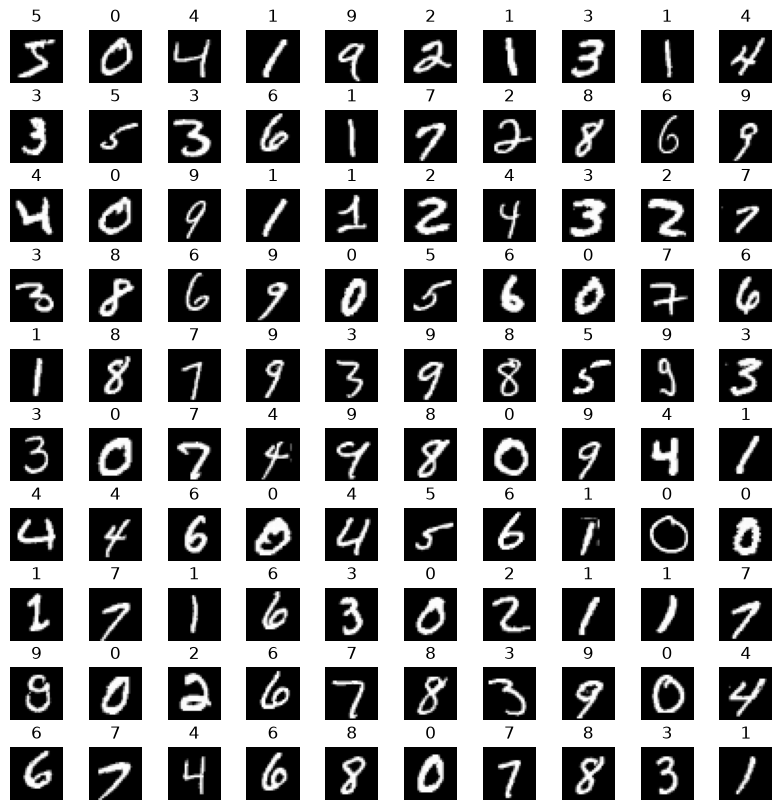

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Rozmiar danych treningowych:", X_train.shape)
print("Rozmiar etykiet treningowych:", y_train.shape)
print("Rozmiar danych testowych:", X_test.shape)
print("Rozmiar etykiet testowych:", y_test.shape)

rows = 10
cols = 10

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.ravel()
for i in range(rows * cols):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"{y_train[i].argmax()}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()



## Sposób wygenerowania wartości początkowych parametrów nuronów (wag)

In [4]:
constant_initializer = tf.keras.initializers.Constant(value=0.1)
random_initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
default_initializer = tf.keras.initializers.GlorotUniform()

kernel_initializer = random_initializer

In [5]:
model = Sequential()

# Dodanie warstw konwolucyjnych i warstw max pooling
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='sigmoid'))


c:\Users\mkowa\.conda\envs\TF\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation = 'softmax'))

In [15]:
model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = 5, strides = 1, activation = 'relu', input_shape = (28,28,1)))
model.add(Conv2D(filters = 32, kernel_size = 5, strides = 1, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = 2, strides = 2))
model.add(Dropout(0.25))
model.add(Conv2D(filters = 64, kernel_size = 3, strides = 1, activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, strides = 1, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = 2, strides = 2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units = 256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(units = 128, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(units = 84, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 10, activation = 'softmax'))

c:\Users\mkowa\.conda\envs\TF\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 32)     │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 64)       │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 84)             │           336 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 275,874 (1.05 MB)

 Trainable params: 274,746 (1.05 MB)

 Non-trainable params: 1,128 (4.41 KB)

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=10, verbose=1,callbacks=early_stopping)
print("Test danych treningowych\n", model.predict(X_train))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9452 - loss: 0.0345
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9745 - loss: 0.0170
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9797 - loss: 0.0141
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9822 - loss: 0.0121
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9845 - loss: 0.0107
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9858 - loss: 0.0096
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9869 - loss: 0.0091
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9880 - loss: 0.0086
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9897 - loss: 0.0072
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9906 - loss: 0.0067
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Test danych treningowych
 [[2.09423018e-14 9.48904380e-1

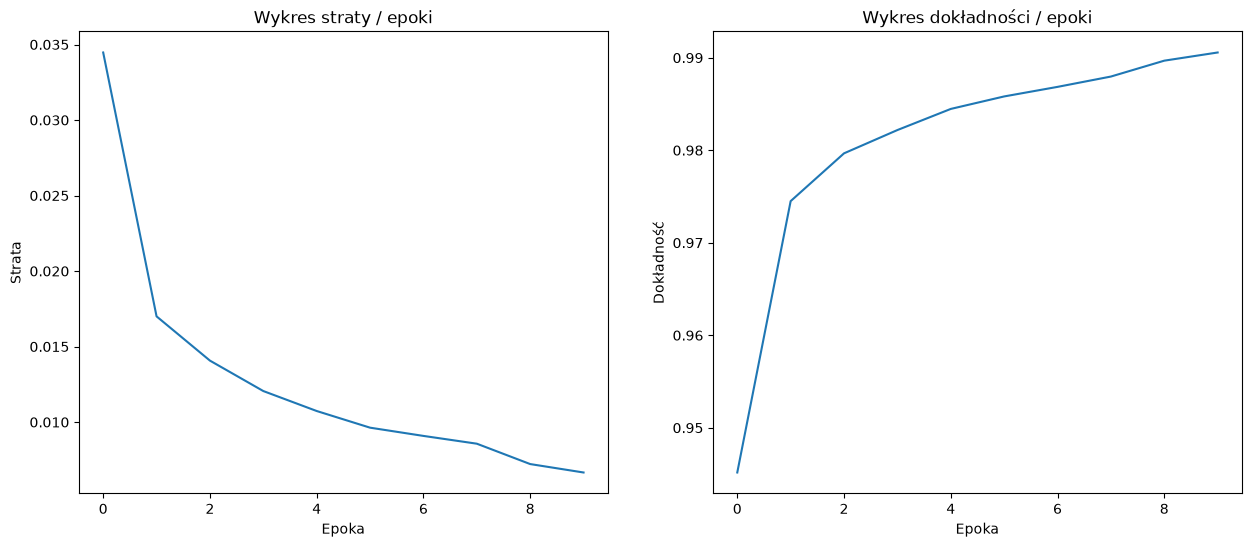

In [18]:
# print('Ewaluacja modelu:', model.evaluate(X_train, y_train))
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].plot(history.history['loss'])
axs[0].set_title('Wykres straty / epoki')
axs[0].set_xlabel('Epoka')
axs[0].set_ylabel('Strata')
# axs[0].set_ylim([0, 1])

axs[1].plot(history.history['accuracy'])
axs[1].set_title('Wykres dokładności / epoki')
axs[1].set_xlabel('Epoka')
axs[1].set_ylabel('Dokładność')
# axs[1].set_ylim([0, 1.2])

plt.show()

In [ ]:
model_name = "cyfry-mnist-test"
model.export(model_name)


INFO:tensorflow:Assets written to: cyfry-mnist-test\assets


INFO:tensorflow:Assets written to: cyfry-mnist-test\assets


Saved artifact at 'cyfry-mnist-test'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_29')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2304154158672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2303545900112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154158864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154157520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154158480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154157328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154158288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154164240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154164048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154164624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2304154157712: TensorSpec(shape=

In [24]:
!python -m tf2onnx.convert --saved-model {model_name} --output {model_name}.onnx
shutil.rmtree(model_name)


I0000 00:00:1781599982.262946   21656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781599983.904237   21656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

2026-06-16 10:53:06,643 - WARNING - From c:\Users\mkowa\.conda\envs\TF\Lib\site-packages\tf2onnx\tf_loader.py:190: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

I0000 00:00:1781599986.649235   21656 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 S